<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Stores_Graphing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Retailer Store Estates

Operational supermarket emissions and energy consumption are expected to positively correlate with retailer size, and vary with the efficiency of estate building, equipment, and transport operations.

In this workbook, the Geolytix Retail Points cleaned in the previous workbook will be explored with the aim of discovering the number and size of retailer stores, and how they have changed.

#  Set-up

## Libraries

In [ ]:
## Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(RColorBrewer)   # Palettes
library(repr)    # Graphic output control
# Set size of output graphic
options(repr.plot.width = 10, repr.plot.height = 8)

## Data

In [ ]:
## Load Data

# Cleaned Geolytix Retail Points
# Store the address of the csv file in a variable named 'url'
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/geolytix_retailpoints_v34_202412_clean.csv"
# Store the path in Colab where the file will be saved to
download_path <- "/content/geolytix_retailpoints_v34_202412_clean.csv"
# Download the file to the destination
download.file(url, destfile = download_path, mode = "wb")
#Import the CSV file to a variable named 'store'
store <- read.csv("/content/geolytix_retailpoints_v34_202412_clean.csv", header=TRUE, stringsAsFactors=FALSE)

In [ ]:
# Summaried Geolytix Retail Points
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/geolytix_retailpoints_v34_202412_summary.csv"
download_path <- "/content/geolytix_retailpoints_v34_202412_summary.csv"
download.file(url, destfile = download_path, mode = "wb")
retailer.yr <- read.csv("/content/geolytix_retailpoints_v34_202412_summary.csv", header=TRUE, stringsAsFactors=FALSE)

In [ ]:
# Retailer Data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)

## Palette

Categorical colour palettes are stored as named lists of key-value pairs that map categories (retailers) to a [hex code](https://colorwikia.com/blog/how-hex-color-codes-work/) (or other colour representation) with which to draw them.

*setNames()* creates a named list from a pair of equal length vectors.

In [ ]:
# Make palette named list from retailer name and hex code
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
retailer.pal

ALDI        ASDA        COOP         ICE        LIDL         M&S 
"#0000FFFF" "#1F9698FF" "#009FFFFF" "#A10300FF" "#B1CC71FF"   "#808080" 
       MORR       OCADO       SAINS        TESC         JLP 
"#02AD24FF" "#783FC1FF" "#FE8F42FF" "#FF0000FF" "#005300FF"

# Sector Trends

It is often a good idea to look at 'the whole' before studying its parts, so let's start by exploring sector-level pattern in store size and area.

Using the summarised retail point, calculate the total number and area of all stores by year.

In [ ]:
# Sum store number and area by year
retailer.yr.all <- retailer.yr %>%
  group_by(year) %>%
  summarise(store = sum(total_store), area = sum(total_area))

retailer.yr.all

year,store,area
<int>,<int>,<int>
2014,12867,9767380
2015,13229,10056200
2016,13591,10244640
2017,14327,10542420
2018,14661,10735620
2019,15163,10965080
2020,15624,11150300
2021,16032,11329360
2022,16702,11535580


## Store Number

Plot store count against year.

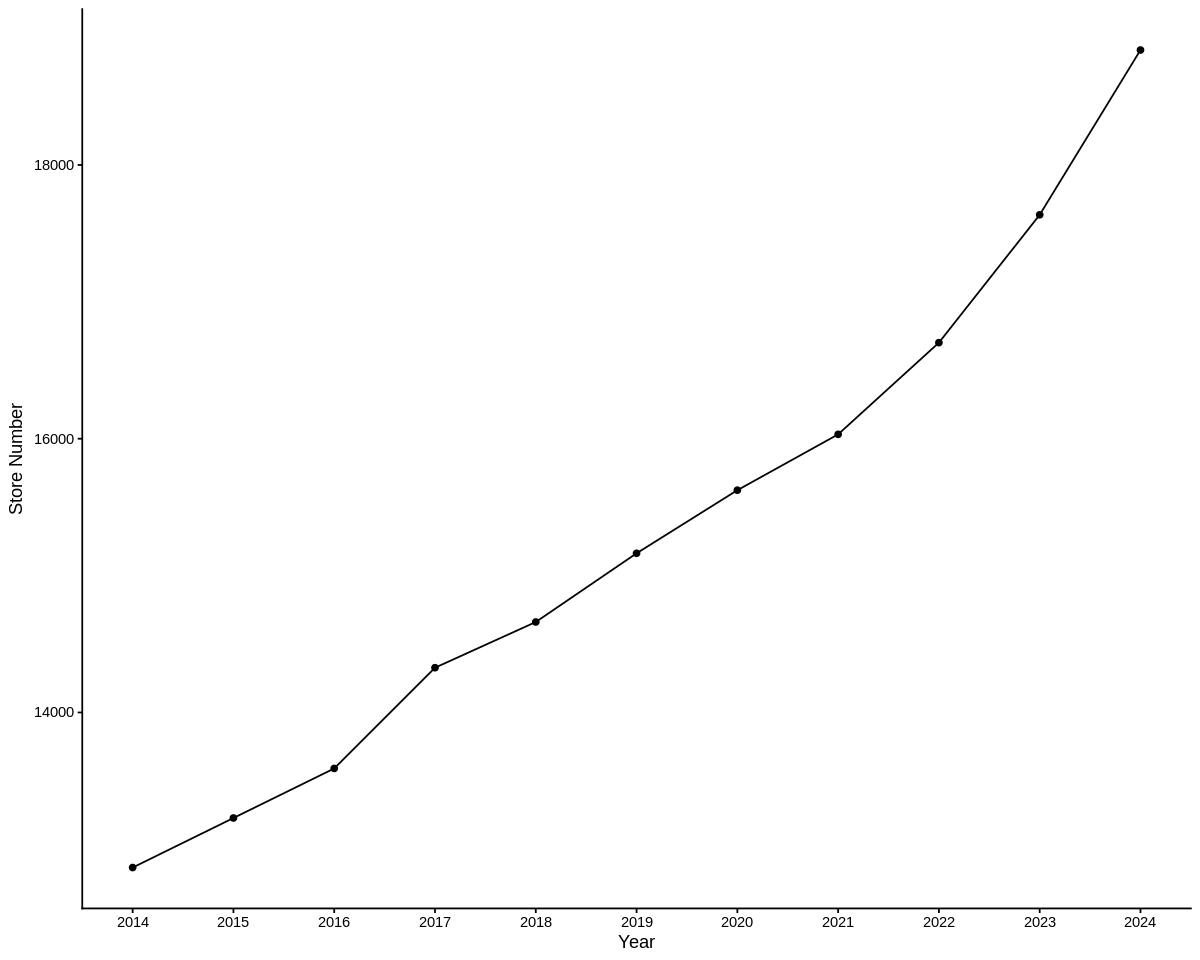

In [ ]:
# Number of stores by year
ggplot(retailer.yr.all, aes(x = year, y = store)) +
  geom_line()  +
  geom_point() +
  xlab("Year") +
  ylab("Store Number") +
  scale_x_continuous(breaks=seq(2014,2024)) +
  theme_classic()

Let's unpick the plot code:

1. `ggplot()` is the main graphing function to which store.yr and a list of `aes()` aesthetics parameters are passed. x specifies the variable assigned to the x-axis of the graph, and y to the y-axis.

2. Additional plot statements are appended with plus ‘+’

3. `geom_line()` plots data values using the default line symbol.

4. `geom_point()` plots values using the default point symbol.

5. `ylab()` and `ylab()` sets the x and y-axis titles.

6. `scale_x_continuous()` sets a manual ticks and labels (breaks) for each year, with `seq()` generating a sequence of integer years to display.

7. `theme_classic()` applies a simple classic theme to the plot.

Now let's consider the pattern and plot design.

* The number of stores steady increases by approximately 50% over the ten year period. Increase is inevitable as closures are not known.

* The upward curve shows number is increasing at a slightly greater than linear.

* The y-axis is scaled to the range of data values so does not communicate how *much* this change is compared the total number of stores.

## Store Area

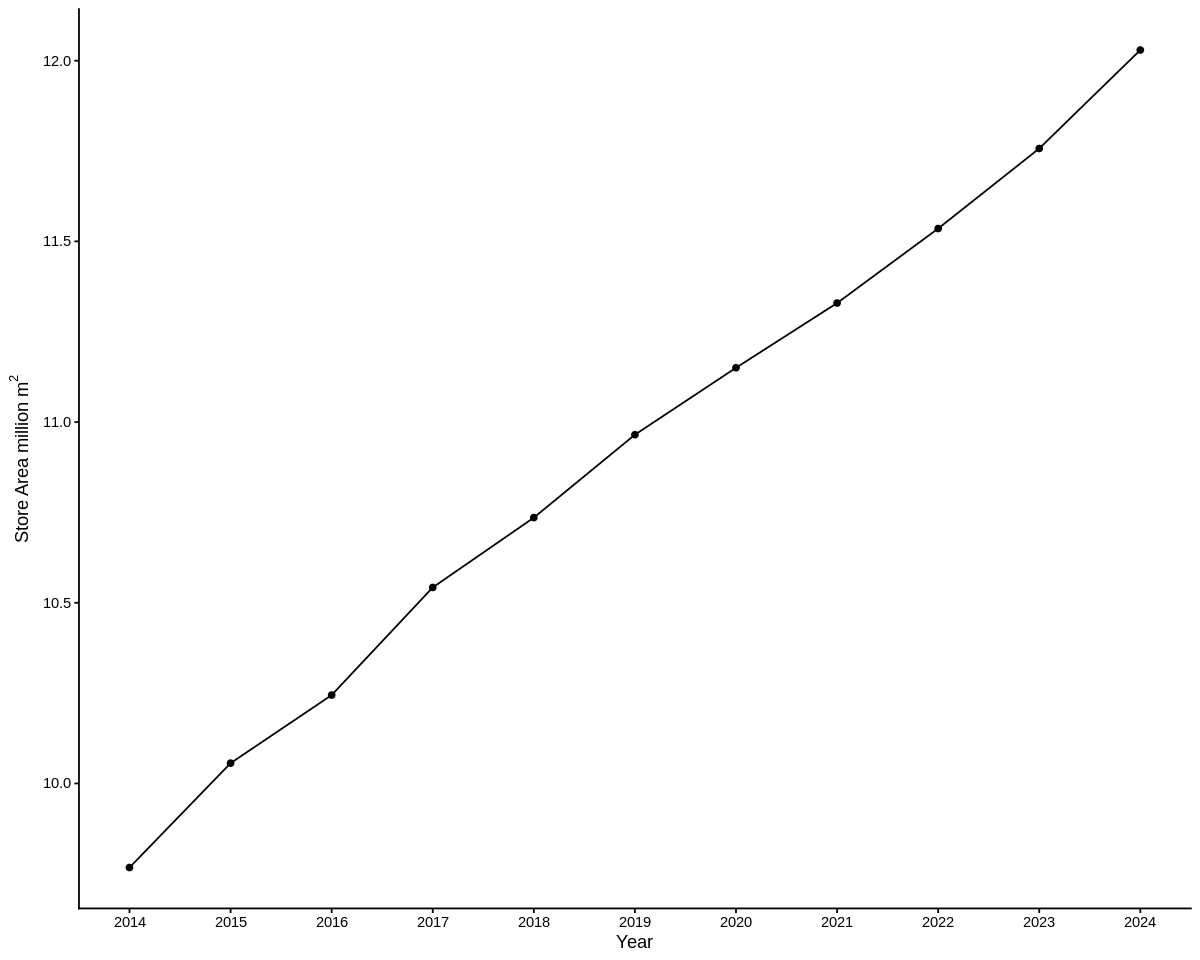

In [ ]:
# Total store area
ggplot(retailer.yr.all, aes(x = year, y = area/1000000)) +
  geom_line()  +
  geom_point() +
  xlab("Year") +
  ylab(expression("Store Area million m"^2)) +
  scale_x_continuous(breaks=seq(2014,2024)) +
  theme_classic()

* Total store area is highly linear with time.

## Store Number and Area

Plotting store number against area reveals how growth in area has slowed compared to store number as sector growth is driven by the opening of smaller stores.

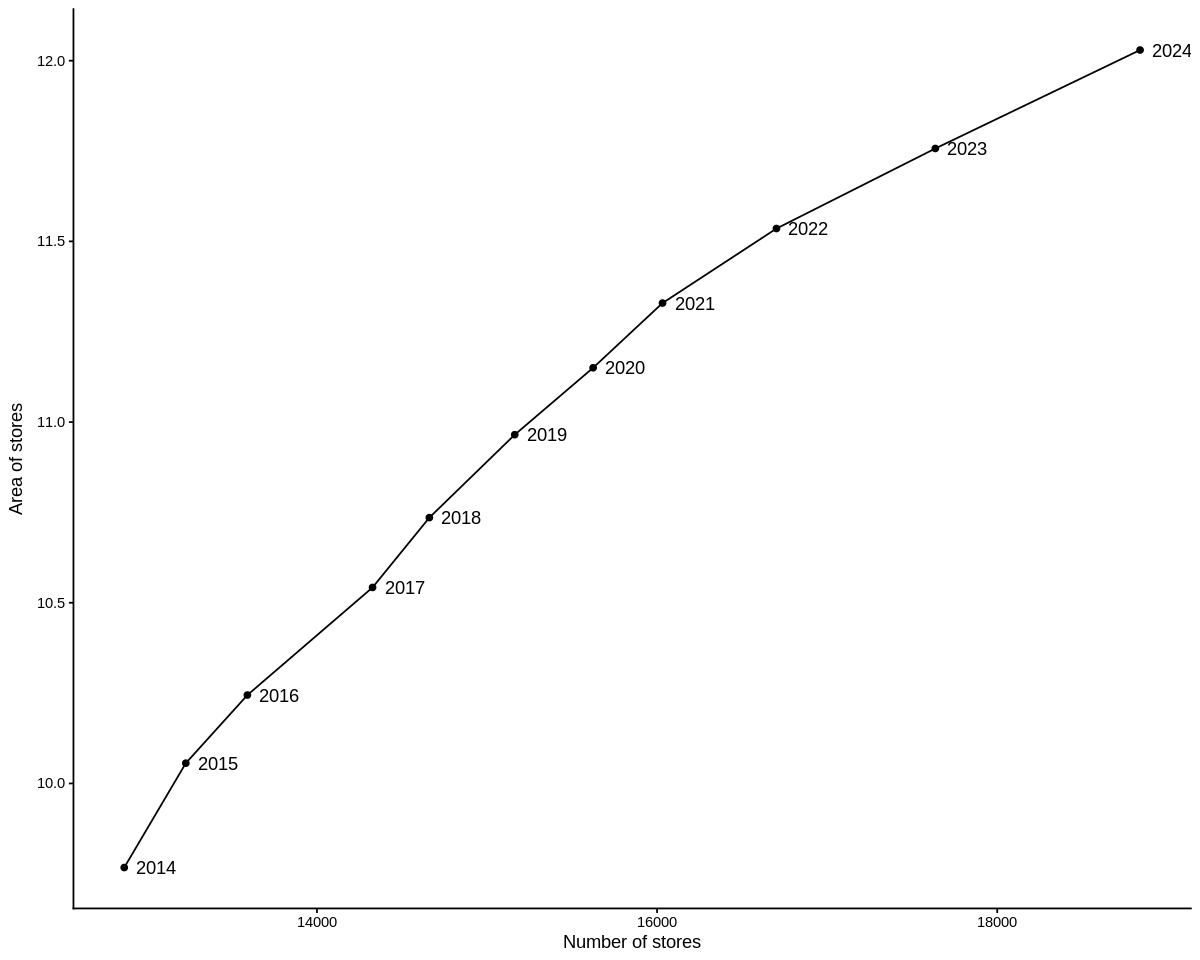

In [ ]:
# Store Number and Area
ggplot(retailer.yr.all, aes(x = store, y = area/1000000)) +
  geom_line()  +
  geom_point() +
  geom_text(aes(label = year), hjust = -0.3) +
  xlab(expression("Number of stores")) +
  ylab(expression("Area of stores")) +
  theme_classic()


* The flatter the curve the smaller mean size of new stores.

Axis limited to the area with data may make change seem greater than it is, so let's plot with axis that start at 0,0.

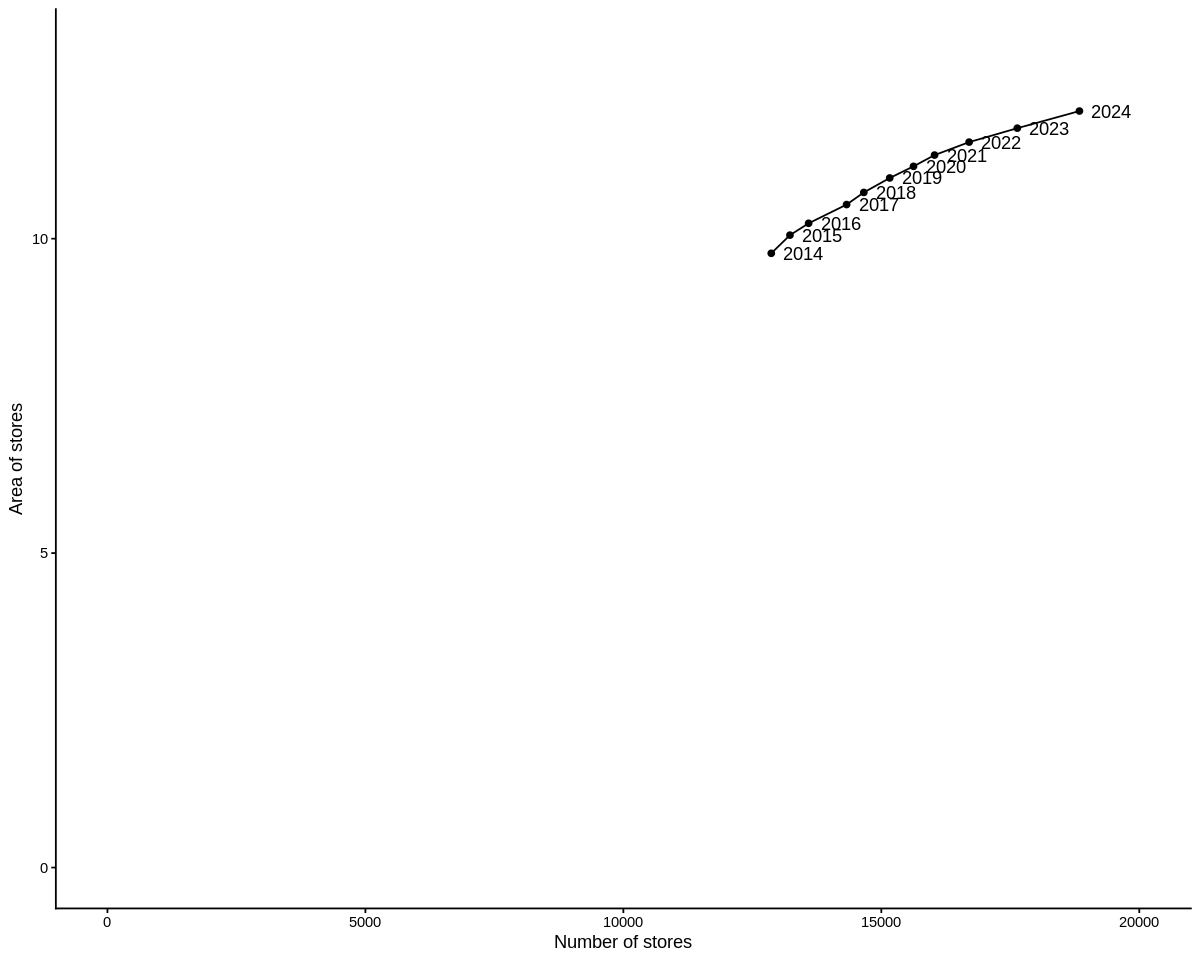

In [ ]:
# Store Number and Area
ggplot(retailer.yr.all, aes(x = store, y = area/1000000)) +
  geom_line()  +
  geom_point() +
  geom_text(aes(label = year), hjust = -0.3) +
  xlab(expression("Number of stores")) +
  ylab(expression("Area of stores")) +
  xlim(0,20000) +
  ylim(0,13) +
  theme_classic()

# Retailers with Emissions Data

Filter to the eleven retails for which there are emissions data. Counting the number of stores and area before and after filtering


In [ ]:
# Before filtering
before <-  retailer.yr %>%
  summarise(total_store = sum(new_store, na.rm = TRUE),
    total_area = sum(new_area, na.rm = TRUE),
    count = n())

before

total_store,total_area,count
<int>,<int>,<int>
18840,12029540,407


In [ ]:
# Filter to eleven retailers
retailers <- as.vector(retailer.data$retailer)
retailer.yr <- retailer.yr %>%
  filter(retailer %in% retailers)

In [ ]:
# After filtering
after <- retailer.yr %>%
  summarise(total_store = sum(new_store, na.rm = TRUE),
    total_area = sum(new_area, na.rm = TRUE),
    count = n())

after

total_store,total_area,count
<int>,<int>,<int>
14176,10974500,110


In [ ]:
# Proportion of store number and area that are owned by the eleven retailers
round(after$total_store/before$total_store, 2)
round(after$total_area/before$total_area, 2)

[1] 0.75

[1] 0.91

The eleven retailers represent 75% of stores and 91% of store area.

## Store Number

Store number is a metric of retailer size so is expected positively correlate with emissions and energy use.

In [ ]:
names(retailer.yr)

[1] "retailer"      "year"          "new_store"     "total_store"  
 [5] "new_area"      "total_area"    "retailer_code" "hex"          
 [9] "revenue_2022"  "revenue_2023"  "mean_revenue"  "cost_index"

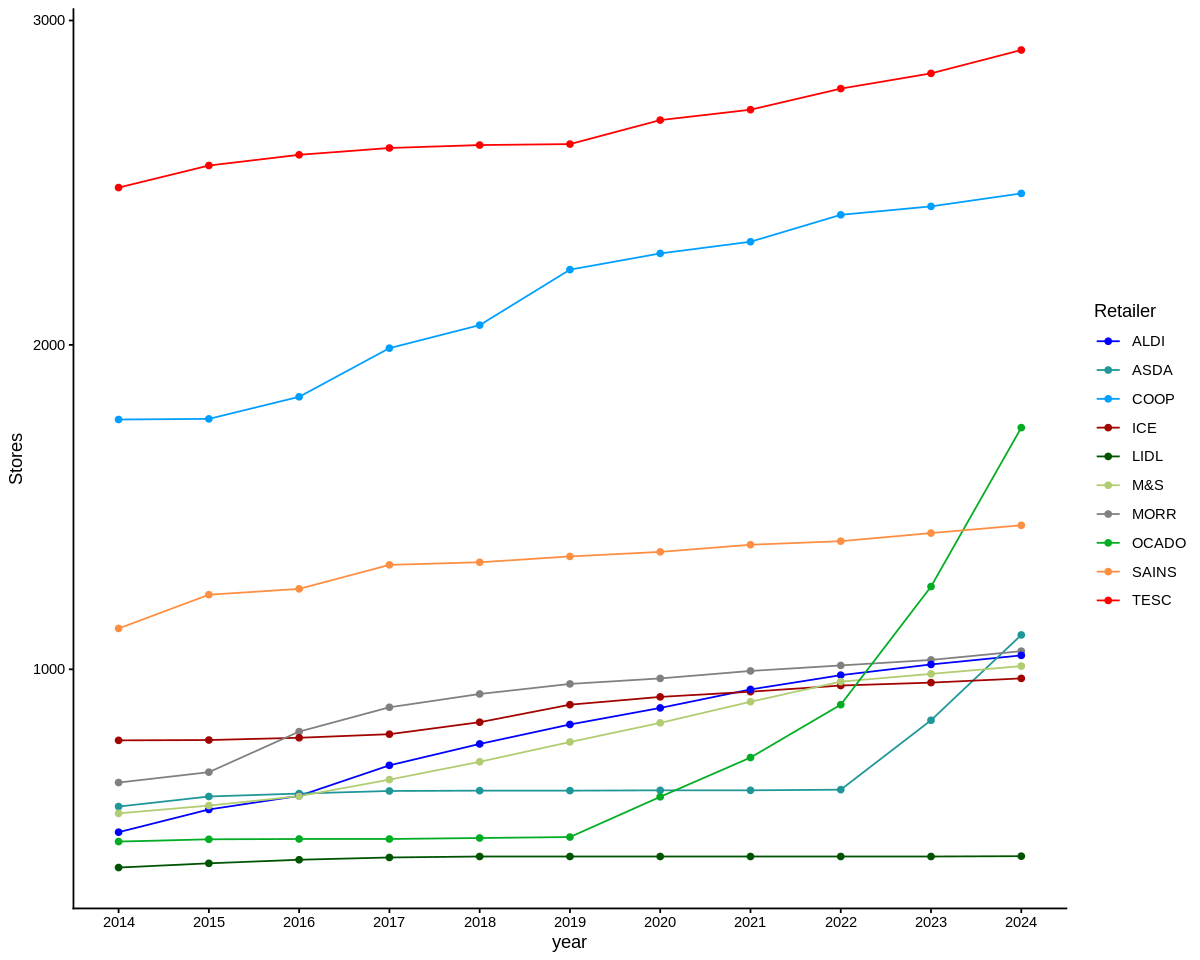

In [ ]:
# # Retailer store number line plot
ggplot(retailer.yr, aes(x = year, y = total_store, colour = retailer_code)) +
   geom_line(na.rm = TRUE) +
   geom_point(na.rm = TRUE) +
   ylab("Stores") +
   scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.data$retailer_code) +
   scale_y_continuous(breaks=seq(0,3) * 1000) +
   scale_x_continuous(breaks=seq(2014, 2024)) +
   theme_classic()

New commands are:

1. `aes()` is passed the 'colour' parameter that sets the colour attribute of drawn graphics to the 'code' field.

2. `geom_line()` and `geom_point()` plot data values using the symbology inheritied from the main `ggplot() `function with the specific colours to use set in `scale_colour_manual()`.  

5. `scale_colour_manual()` matches the ggplot colour value to the retailer.pal  colour map.


* Tesco has the most stores, with the Cooperative Group second with a large gap between the two leaders and the rest.

* Retailers expanded at different rates at different times with Morrisons opening many stores in 2020 onwards, and Asda showing a similar meteoric rise from 2023.

* Waitrose is the smallest retailer by store number and has expanded the least.

* Most y-values are less than 1000 so most data is dislayed in the bottom third of the graph reducing readability where data is dense.

* The plot allows the comparison of store number of each retailer but does not show the relative number of retailer stores *in relation to the total number of stores.

Let's plot the same data as a stacked area plot.

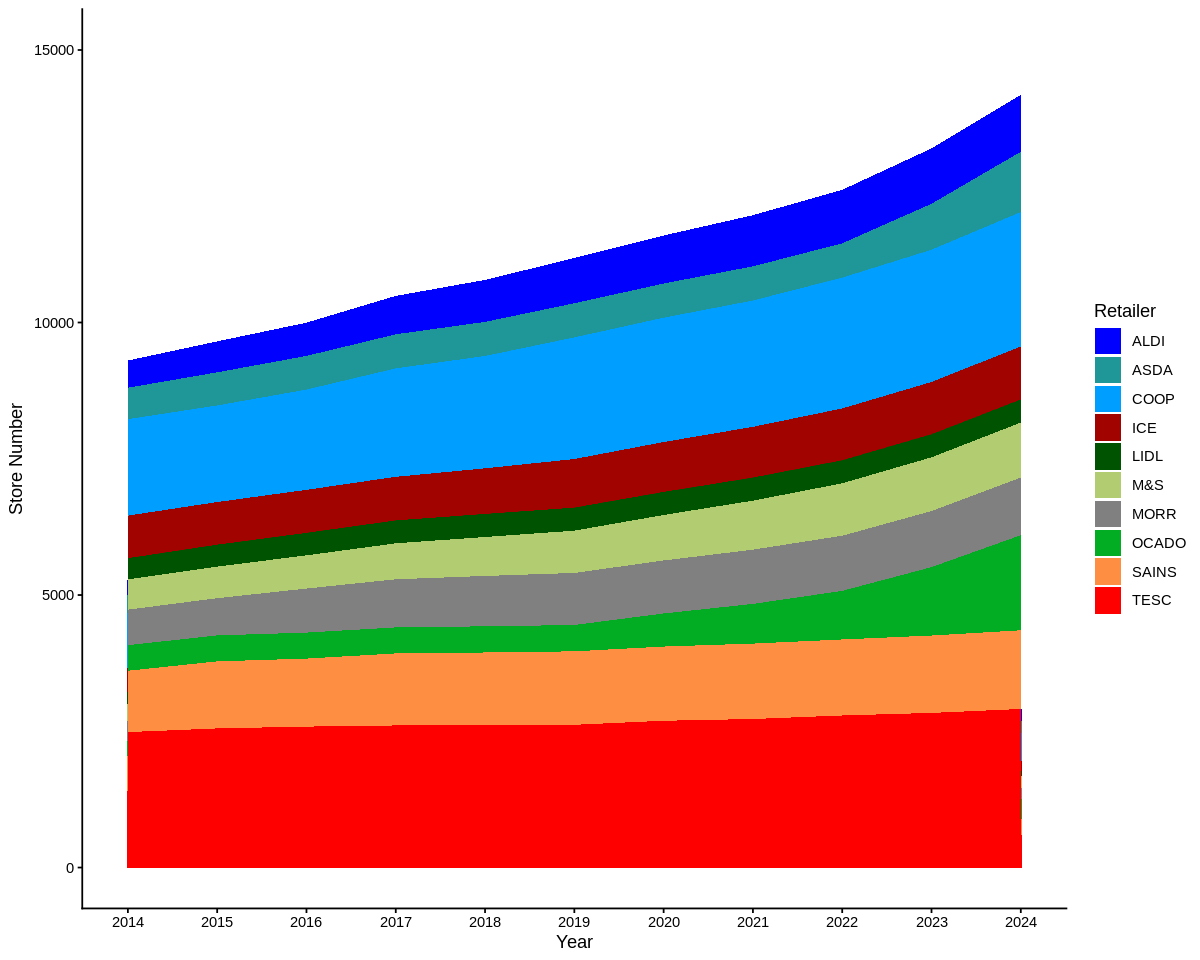

In [ ]:
# Retailer store number area plot
ggplot(retailer.yr, aes(x = year, y = total_store, fill = retailer_code)) +
  geom_area(na.rm = TRUE) +
  xlab("Year") +
  ylab("Store Number") +
  scale_x_continuous(breaks=seq(2014,2024)) +
  scale_y_continuous(limits = c(0,15000), breaks=seq(0,5) * 5000) +
  scale_fill_manual(name = "Retailer", values = retailer.pal, labels = retailer.data$retailer_code) +
  theme_classic()

* Provides a good overview of sector size and its distribution among retailers.

* Variation in retailers is supressed as the y-axis extends to the maximum sum of store number.


## Store Area

Store area is a metric of retailer size so is expected positively correlate with emissions and energy use.

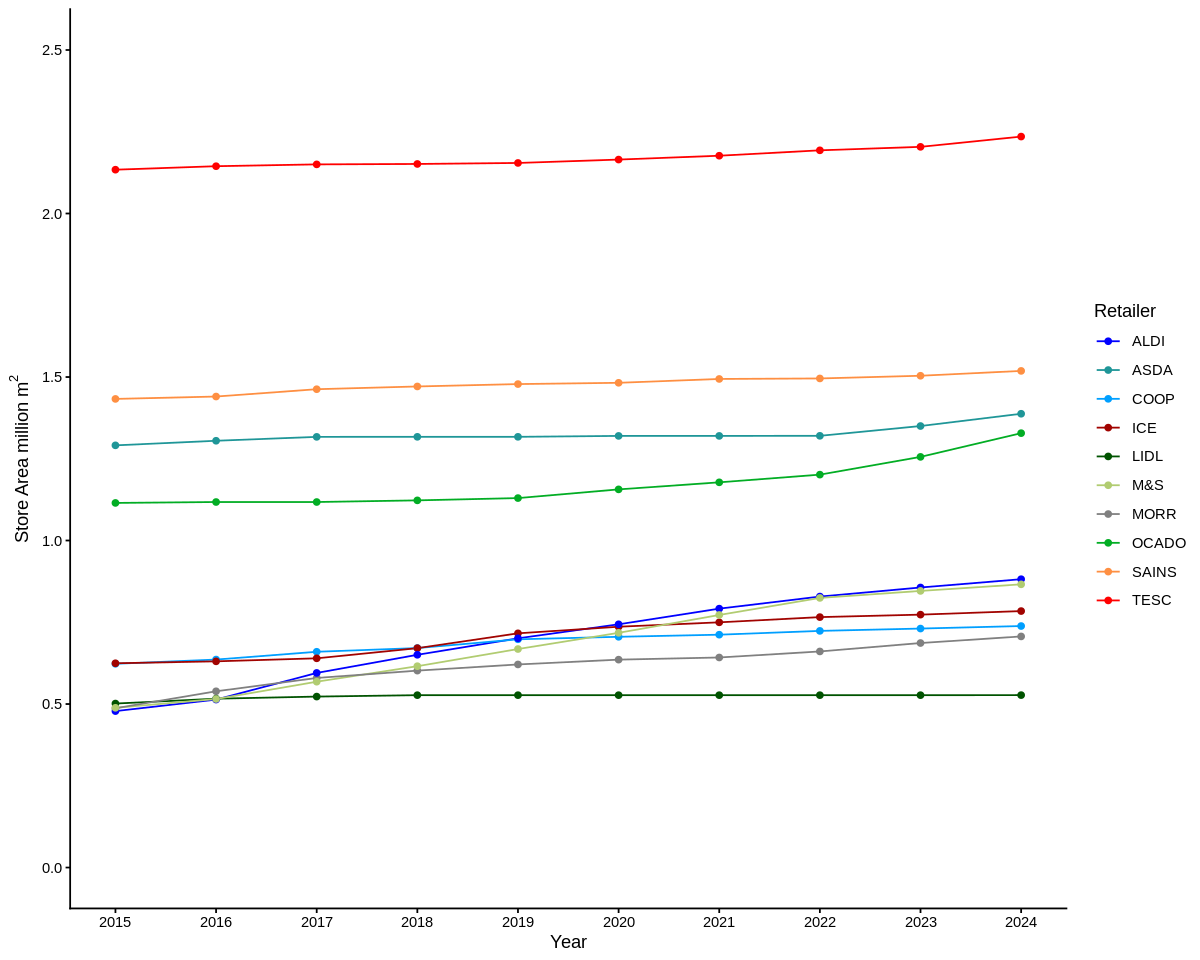

In [ ]:
# Retailer store area
ggplot(retailer.yr, aes(x = year, y = total_area/1000000, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  xlab("Year") +
  ylab(expression("Store Area million m"^2)) +
  scale_x_continuous(limits = c(2015,2024), breaks=seq(2015,2024)) +
  scale_y_continuous(limits = c(0,2.5), breaks=seq(0,5)/2) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.data$retailer_code) +

  theme_classic()

* Retailers fall into three groups by store area, Tesco is alone as the largest retailer by store area, followed by Sainsbury's, Asda, and Morrisons, collectively known as 'The Big Four'. The remaining supermakets bunch between 0.5 and 1 million m<sup>2</sup> floor space. The online retailer Ocado has no physical stores so is a fourth class.

* Ocado is included on the legend but is not on the plot as they have no stores.

## Store Number and Area

Plotting retailer store number against area by year shows how retailer total estate portfolios have grown year-on-year.


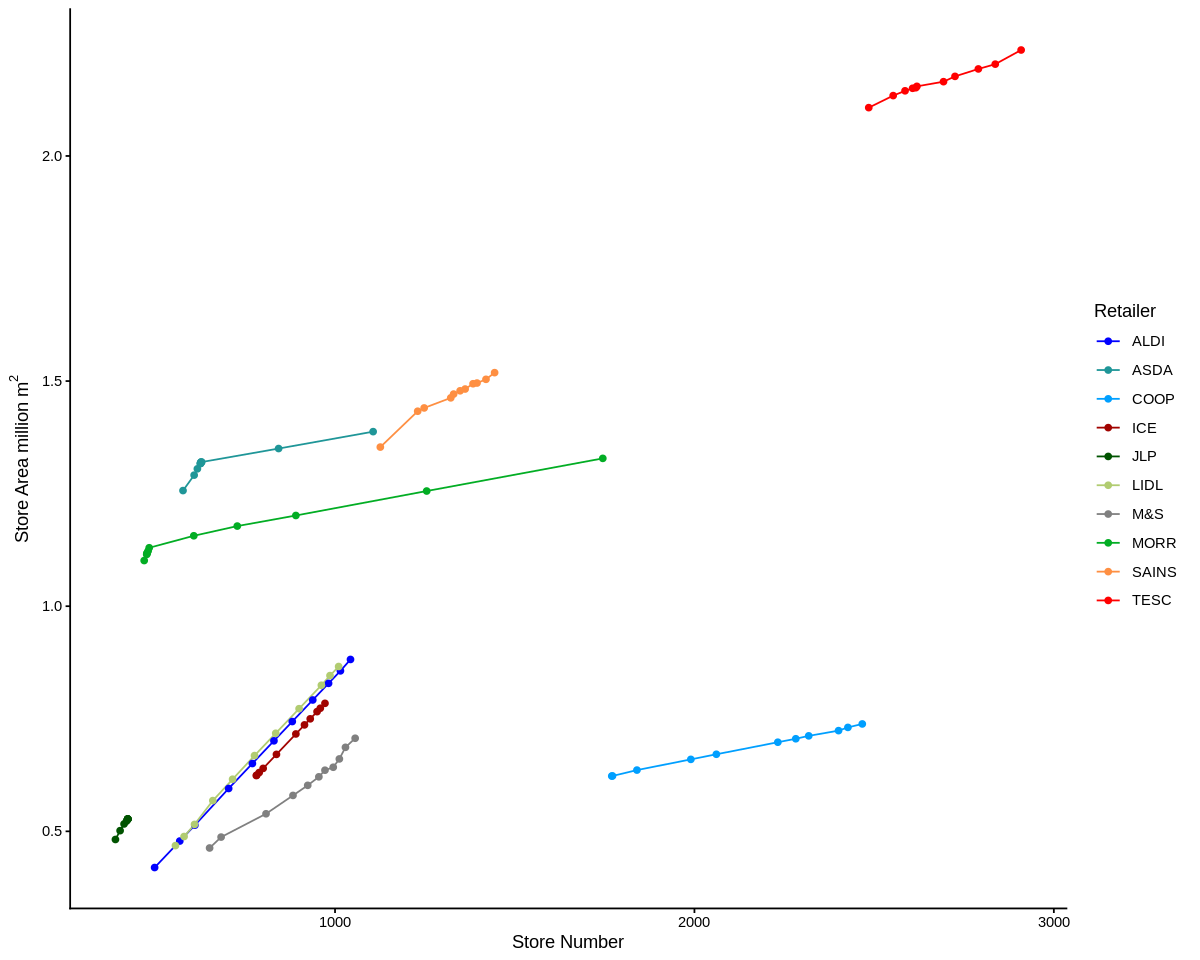

In [ ]:
# Scatter plot
ggplot(retailer.yr, aes(x = total_store,
                        y = total_area/1000000,
                        colour = retailer_code,
                        labels = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  xlab("Store Number") +
  ylab(expression("Store Area million m"^2)) +
  scale_colour_manual(name = "Retailer", values = retailer.pal) +
  theme_classic()

* Larger retailers are further from the origin than smaller retailers.

* The mean size of 'Big Four' stores is greater than other retailers with Tesco standing out as the largest retailer by both store number and area. In contrast, the average size of COOP stores is smaller than other retailers.

* Store closure is not recorded so retailer store number and area increase year-on-year.

* The greater the slope, the larger the average size of new stores.

* Change in slope occur when a retailer's store aquistion policy changes, for example, Asda and Morrisons both changed to investing in new smaller stores.

# Store Portfolios

Emissions and energy use may vary with the store size and age. For example, operating and maintaining a modern portfolio of stores with similar design may be expected to be more efficient than a portfolio of diverse older stores.

A deeper understanding of retailer store portfolios can be obtained from the cleaned retail points.

In [ ]:
# Download Data from GitHub
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/geolytix_retailpoints_v34_202412_clean.csv"
download_path <- "/content/geolytix_retailpoints_v34_202412_clean.csv"
download.file(url, destfile = download_path, mode = "wb")

# Import the cleaned csv of stores to the variable named store
store <- read.csv("/content/geolytix_retailpoints_v34_202412_clean.csv", header=TRUE, stringsAsFactors=FALSE)


In [ ]:
# Filter to eleven retailers
store <- filter(store, retailer %in% retailer.data$retailer)

Let's create a barchart of the number of stores in each class.

`geom_bar()` plots a bar chart of the count of each store_level which correspond to the size class order (1 = small store, 5 = hypermarket).

`geom_text()` adds the count above each bar.

This is a graphic version of the counts returned by `table(store$size_level)`.

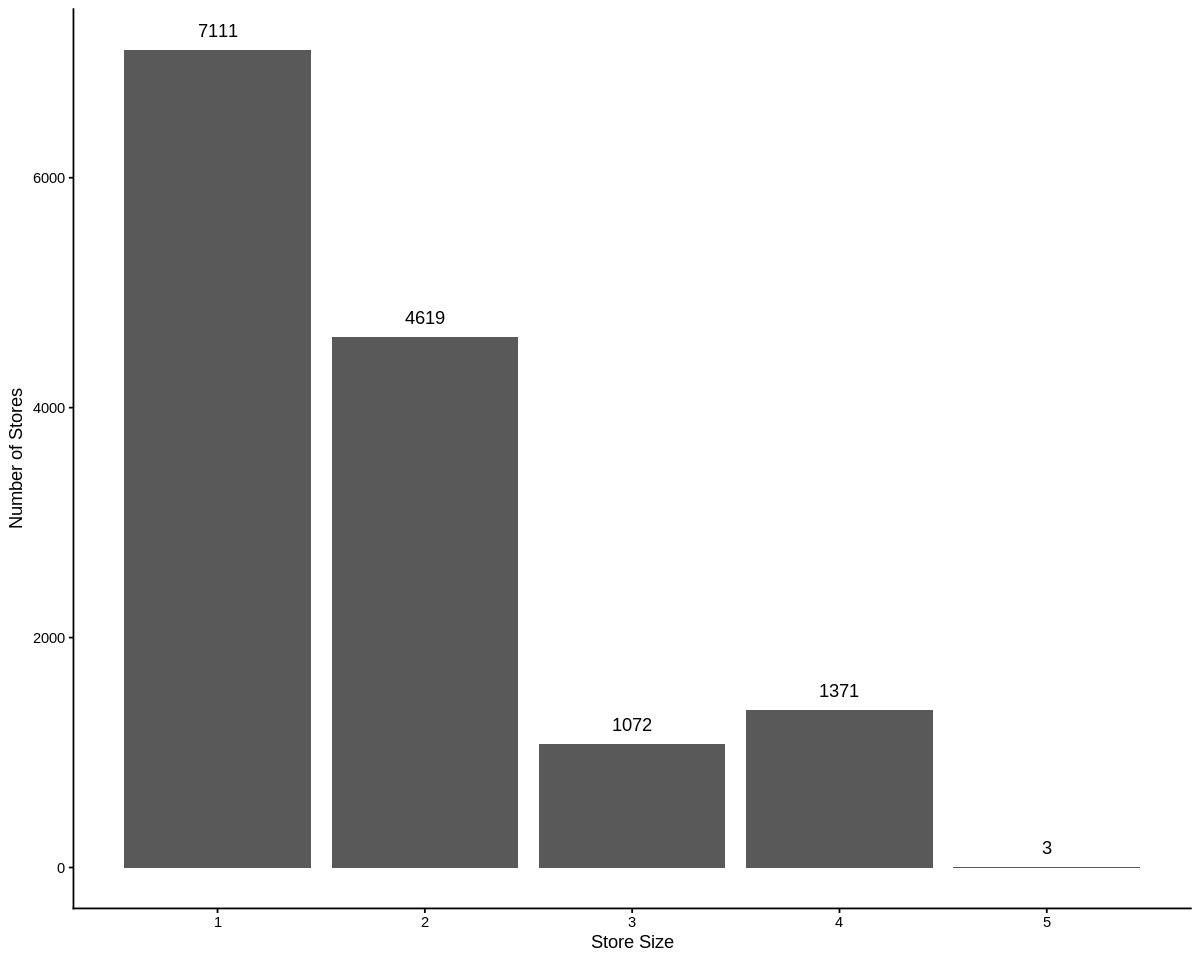

In [ ]:
ggplot(store, aes(x = size_level)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust=-1) +
  xlab("Store Size") +
  ylab("Number of Stores") +
  theme_classic()

* It is unsurprising that there are more small stores than large stores.

* The greater number of size level 4 than level 3 may not have been. Large 'hypermarkets' often sell clothes and household goods as well as food, so perhaps the jump in size is required to accomodate a sufficient range of products?

Plot a stacked bar chart of the number of stores of each size class by retailer.

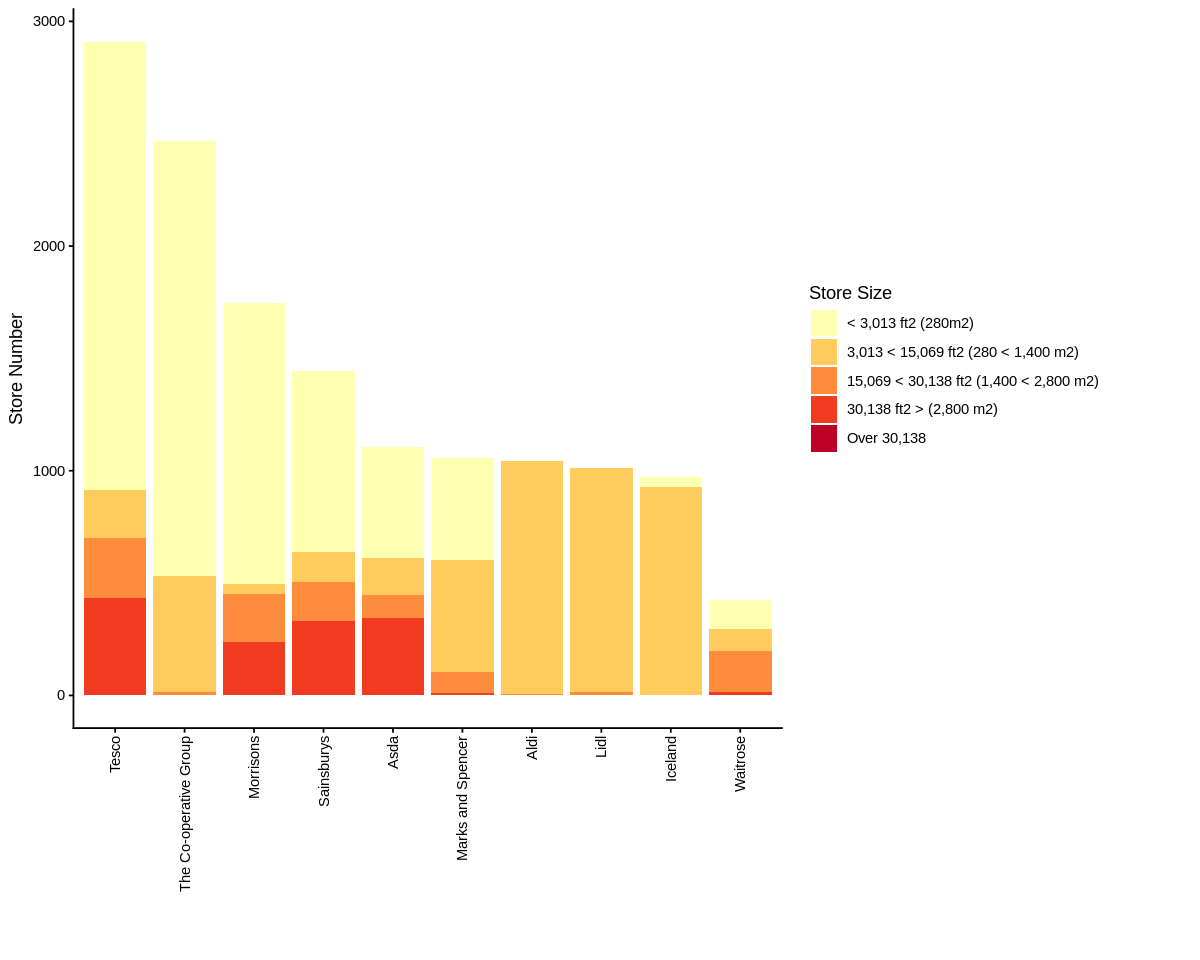

In [ ]:
ggplot(store, aes(
            x = forcats::fct_reorder(retailer, retailer, .fun=length, .desc = TRUE),
            fill = as.character(size_level))) +
  geom_bar(position="stack") +
  xlab("") +
  ylab("Store Number") +
  scale_fill_brewer(palette = "YlOrRd",name = "Store Size",
     labels = unique(store$size_band)) +
  theme_classic() +
 theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

`geom_bar(position="stack")` draws a stacked bar chart of counts by retailer (the x-axis).

`scale_fill_brewer()` is used as bar sections are to be assigned colours to size_level values.

As always, what pattern do you observe in the plot?

* Aldi, Aldi and Lidl stores are almost exclusively in the second size class.

* The Coop has mostly smaller stores, and Waitrose (JLP) and Marks and Spencer few hypermarkets.

* Other retailers have a range of store sizes in their portfolios which are mostly small or large with Asda having a larger proportion bigger stores.


# Store Location

The spatial distribution of stores may impact scope 1 and 2 emissions and energy usage through varying transport requirements.

In [ ]:
# Join retailer attributes to store
store <- merge(store, retailer.data, by = "retailer")

Plot the geographic distribution of the stores of the eleven retailers.

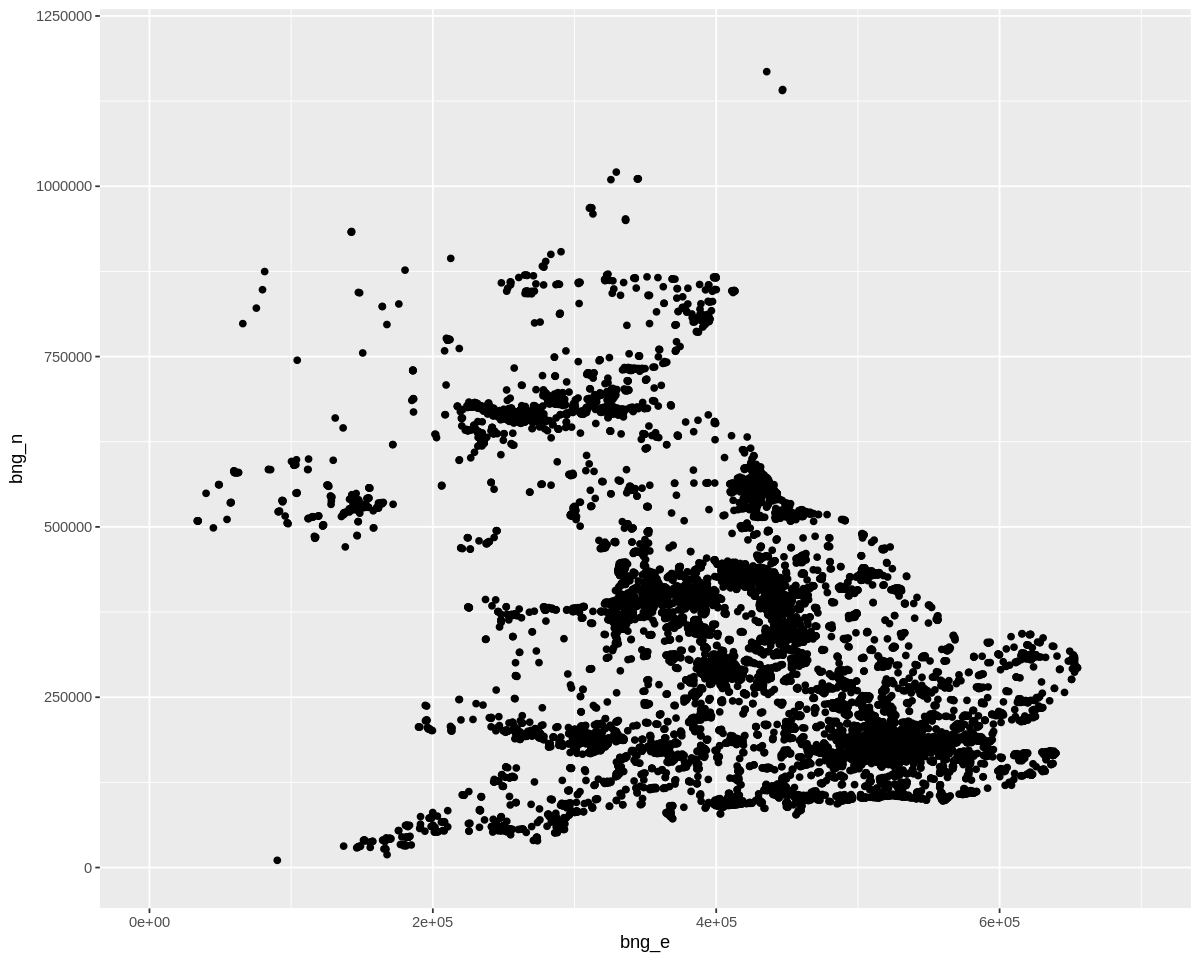

In [ ]:
ggplot(store, aes(x = bng_e, y = bng_n)) +
  geom_point(na.rm = TRUE) +
  ylim(0,1200000) +
  xlim(0,700000)


Let's compare two retailers.

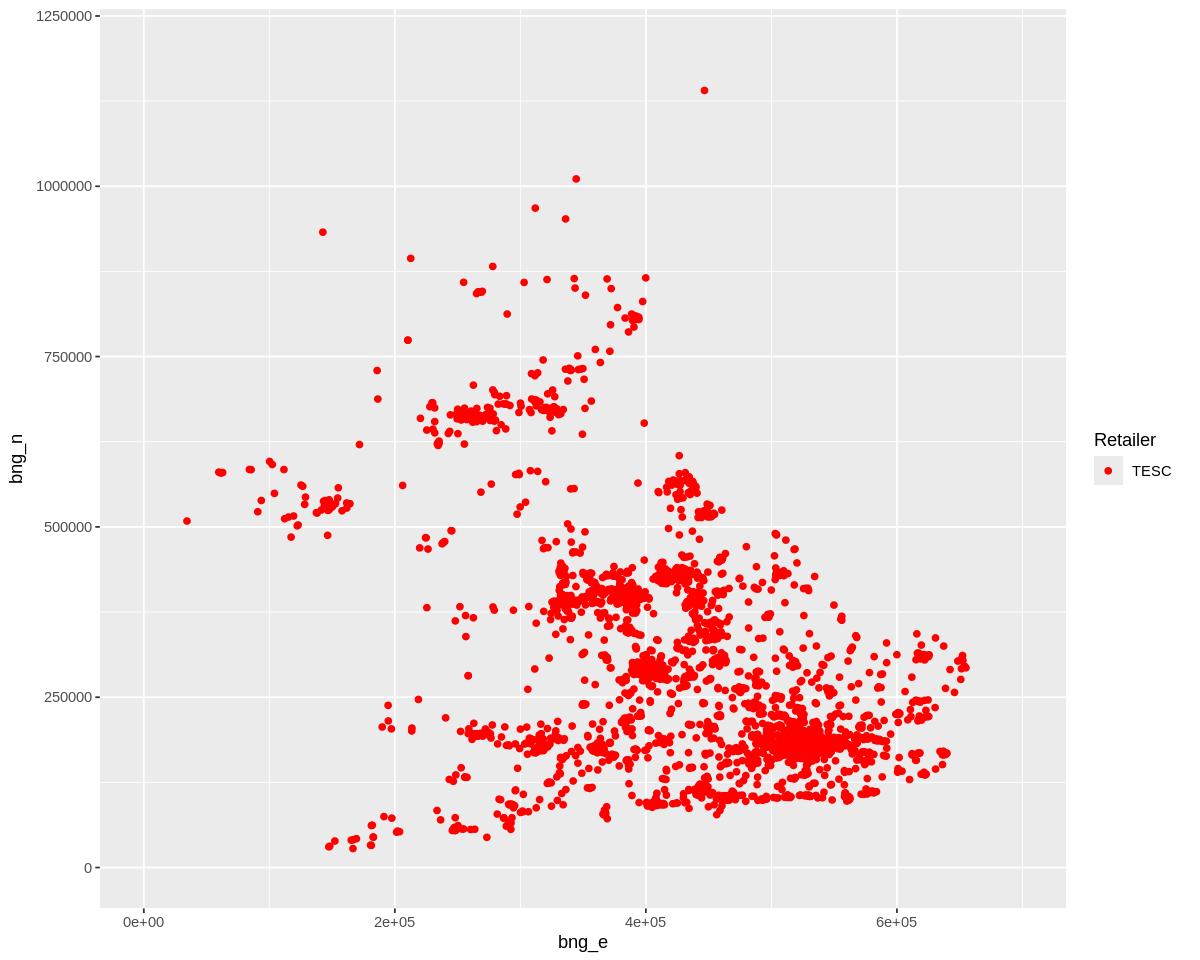

In [ ]:
data <- filter(store, retailer == "Tesco")
ggplot(data, aes(x = bng_e, y = bng_n,
                        colour = retailer_code,
                        labels = retailer_code)) +
  geom_point(na.rm = TRUE) +
  ylim(0,1200000) +
  xlim(0,700000) +
  scale_colour_manual(name = "Retailer", values = retailer.pal)


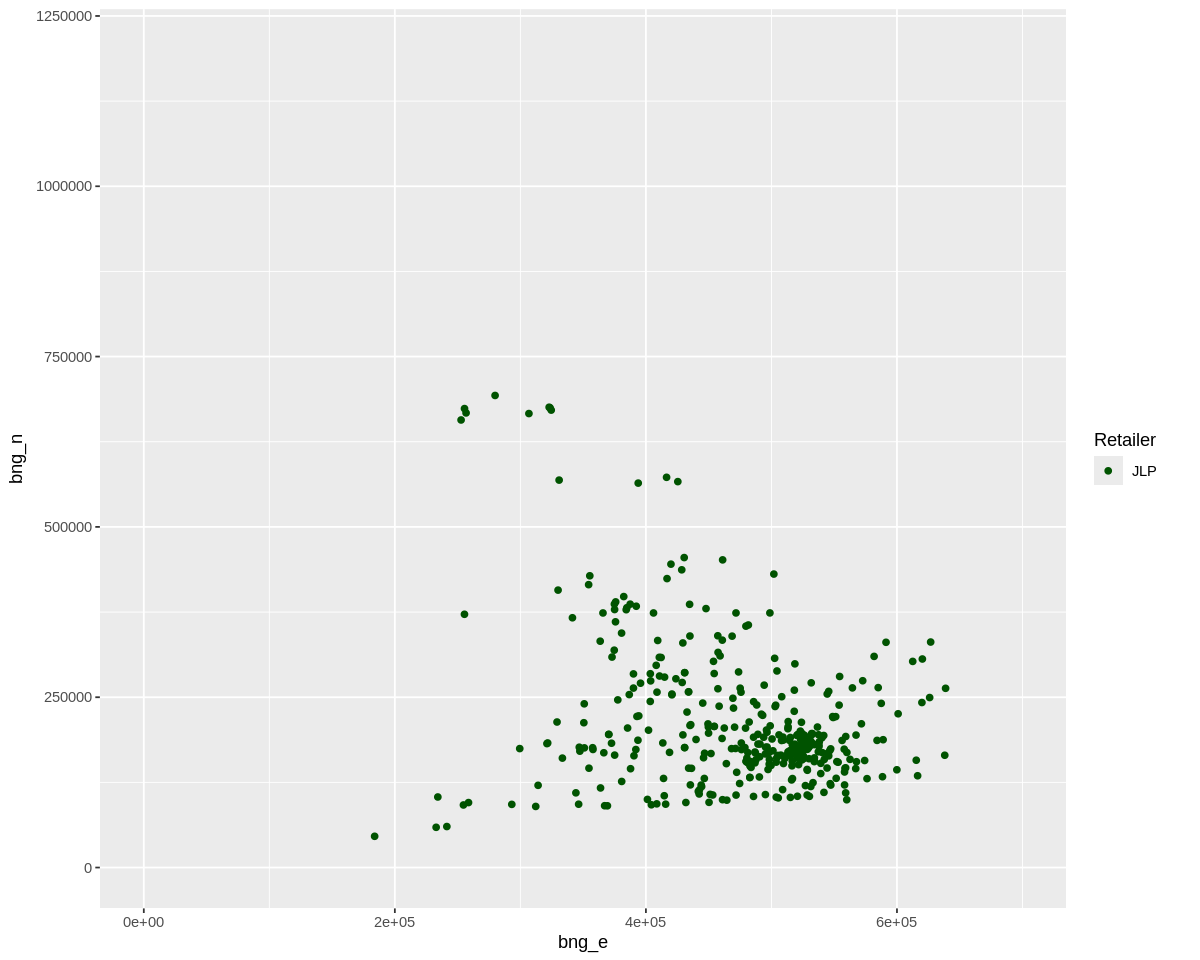

In [ ]:
data <- filter(store, retailer == "Waitrose")
ggplot(data, aes(x = bng_e, y = bng_n,
                        colour = retailer_code,
                        labels = retailer_code)) +
  geom_point(na.rm = TRUE) +
  ylim(0,1200000) +
  xlim(0,700000) +
  scale_colour_manual(name = "Retailer", values = retailer.pal)


* Tesco has a denser and more extensive network of stores than Waitrose.

# Summary

You should now have a picture of the UK supermarket sector over the last 10 years.

* The eleven retailers represent 91% of UK supermarket store area.

* All retailers have increased in size but closures are not recorded.

* Morrissons has recent high growth.

* Retailer store portfolios vary in store number, size, and spatial distribution

---

Back: [Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

Next: [Emissions Cleaning](https://colab.research.google.com/drive/1NHQ3zSObh-RvuGAsi7BlKqz_gkpDFlHn#scrollTo=2kNWI-8-2mYF)

---
